# Text Style Detection — Notebook 03
## Pre-trained Embeddings + MultiOutputClassifier

**Upgrade over `modelling_02.ipynb`:**
- Replace sparse TF-IDF vectors with dense **spaCy `en_core_web_md`** word vectors (GloVe-based, 300-d), averaged across tokens → one document vector per sample.
- Use **`MultiOutputClassifier`** to handle both target labels jointly in a single pipeline instead of two separate models.
- Compare **SVM (RBF kernel)** vs **Random Forest** as base estimators.
- Full cross-validated evaluation with per-label and joint classification reports.

### Why pre-trained embeddings beat TF-IDF here
TF-IDF is purely frequency-based and treats every word as independent. Word vectors capture **semantic similarity** ("formal" ≈ "official", "slang" ≈ "colloquial") so the classifier can generalise to unseen vocabulary. spaCy's medium/large vectors are a good no-download default; alternatives (FastText, GloVe-Twitter, Word2Vec) are discussed at the bottom.

## 1. Imports & Setup

In [28]:
import warnings

warnings.filterwarnings('ignore')

import joblib
import os

from pathlib import Path
import numpy as np
import pandas as pd
import spacy
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

print('All imports OK')

All imports OK


## 2. Load spaCy Model with Word Vectors

We need `en_core_web_md` (or `en_core_web_lg`) for 300-d word vectors.
Run once if not already downloaded:
```bash
python -m spacy download en_core_web_md
```

In [50]:
try:
    nlp = spacy.load('en_core_web_md')
    print(f'Loaded en_core_web_md — vocab vectors: {nlp.vocab.vectors.shape}')
except OSError:
    try:
        nlp = spacy.load('en_core_web_lg')
        print(f'Loaded en_core_web_lg — vocab vectors: {nlp.vocab.vectors.shape}')
    except OSError:
        nlp = spacy.load('en_core_web_sm')
        print('WARNING: loaded en_core_web_sm which has no word vectors.')
        print('Install a bigger model: python -m spacy download en_core_web_md')

VECTOR_SIZE = nlp.vocab.vectors_length
print(f'Vector size: {VECTOR_SIZE}')

Loaded en_core_web_md — vocab vectors: (20000, 300)
Vector size: 300


## 3. Custom Sklearn Transformer — SpaCy Embedding Vectoriser

We wrap the spaCy doc-vector logic in a proper `TransformerMixin` so it slots directly into a `Pipeline`.

In [51]:
class SpacyEmbeddingVectoriser(BaseEstimator, TransformerMixin):
    """
    Converts a list/Series of text strings into a 2-D numpy array
    of shape (n_samples, vector_size) using spaCy vectors.

    The vector size is determined once during fit(), so transform()
    always returns consistent feature dimensions.
    """

    def __init__(self, nlp=None, batch_size: int = 64):
        self.nlp = nlp
        self.batch_size = batch_size
        self.vector_size_ = None

    def fit(self, X, y=None):
        if self.nlp is None:
            raise ValueError("nlp must be provided.")

        if self.nlp.vocab.vectors_length > 0:
            self.vector_size_ = self.nlp.vocab.vectors_length
            return self

        for text in X:
            doc = self.nlp("" if text is None else str(text))
            doc_vector = np.asarray(doc.vector, dtype=np.float32)

            if doc_vector.ndim == 1 and doc_vector.size > 0:
                self.vector_size_ = doc_vector.size
                return self

        raise ValueError(
            "Could not determine vector size. "
            "The loaded spaCy model does not produce usable vectors."
        )

    def _text_to_vector(self, text: str) -> np.ndarray:
        if self.vector_size_ is None:
            raise ValueError("Vectoriser is not fitted. Call fit() before transform().")

        doc = self.nlp("" if text is None else str(text))

        vectors = [
            np.asarray(token.vector, dtype=np.float32)
            for token in doc
            if not token.is_stop
               and not token.is_punct
               and np.asarray(token.vector).ndim == 1
               and np.asarray(token.vector).size == self.vector_size_
        ]

        if vectors:
            return np.mean(vectors, axis=0).astype(np.float32)

        doc_vector = np.asarray(doc.vector, dtype=np.float32)

        if doc_vector.ndim == 1 and doc_vector.size == self.vector_size_:
            return doc_vector

        return np.zeros(self.vector_size_, dtype=np.float32)

    def transform(self, X, y=None):
        if self.vector_size_ is None:
            self.fit(X)

        texts = list(X)
        vectors = [self._text_to_vector(t) for t in texts]

        return np.vstack(vectors)

## 4. Load Dataset

In [56]:
DATA_PATH = 'data/dataset.csv'

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head(3)

(1000, 4)


,text,clean_text,style,tone
0,"The sheer, unadulterated arrogance required to...","the sheer , unadulterated arrogance require to...",academic,aggressive
1,It is entirely baffling how an executive manag...,it be entirely baffle how an executive manager...,business,aggressive
2,Your team has aggressively managed to complete...,your team have aggressively manage to complete...,business,aggressive


In [57]:
TEXT_COL = 'text'
TARGET_1 = 'style'
TARGET_2 = 'tone'

print('Target 1 distribution:')
print(df[TARGET_1].value_counts())
print()
print('Target 2 distribution:')
print(df[TARGET_2].value_counts())

Target 1 distribution:
style
academic    200
business    200
informal    200
formal      200
literaly    200
Name: count, dtype: int64

Target 2 distribution:
tone
aggressive    200
sarcastic     200
neutral       200
urgent        200
friendly      200
Name: count, dtype: int64


## 5. Encode Labels & Split

In [58]:
le1 = LabelEncoder()
le2 = LabelEncoder()

df['label_1'] = le1.fit_transform(df[TARGET_1])
df['label_2'] = le2.fit_transform(df[TARGET_2])

print(f'{TARGET_1} classes: {list(le1.classes_)}')
print(f'{TARGET_2} classes: {list(le2.classes_)}')

X = df[TEXT_COL]
y = df[['label_1', 'label_2']].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y[:, 0]
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

style classes: ['academic', 'business', 'formal', 'informal', 'literaly']
tone classes: ['aggressive', 'friendly', 'neutral', 'sarcastic', 'urgent']
Train: 800 | Test: 200


## 6. Pre-compute Embedding Matrices

We pre-compute once and reuse, so we don't re-embed thousands of texts for every CV fold.

In [59]:
vectoriser = SpacyEmbeddingVectoriser(nlp=nlp)

print('Vectorising training set...')
X_train_vec = vectoriser.transform(X_train)

print('Vectorising test set...')
X_test_vec = vectoriser.transform(X_test)

print(f'Train matrix: {X_train_vec.shape}')
print(f'Test  matrix: {X_test_vec.shape}')

Vectorising training set...
Vectorising test set...
Train matrix: (800, 300)
Test  matrix: (200, 300)


## 7. Model 1 — MultiOutputClassifier wrapping SVM (RBF)

`MultiOutputClassifier` fits one independent classifier per output column, but we manage both in a single sklearn-compatible object — no more manual loops or mismatched indices.

In [60]:
svm_base = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

svm_multi = MultiOutputClassifier(svm_base, n_jobs=-1)
svm_multi.fit(X_train_vec, y_train)

y_pred_svm = svm_multi.predict(X_test_vec)

print('=' * 60)
print(f'SVM — {TARGET_1} ({le1.classes_})')
print('=' * 60)
print(
    classification_report(
        y_test[:, 0], y_pred_svm[:, 0],
        target_names=le1.classes_
    )
)

print('=' * 60)
print(f'SVM — {TARGET_2} ({le2.classes_})')
print('=' * 60)
print(
    classification_report(
        y_test[:, 1], y_pred_svm[:, 1],
        target_names=le2.classes_
    )
)

SVM — style (['academic' 'business' 'formal' 'informal' 'literaly'])
              precision    recall  f1-score   support

    academic       0.95      0.88      0.91        40
    business       0.78      0.80      0.79        40
      formal       0.82      0.82      0.82        40
    informal       0.83      0.95      0.88        40
    literaly       1.00      0.90      0.95        40

    accuracy                           0.87       200
   macro avg       0.88      0.87      0.87       200
weighted avg       0.88      0.87      0.87       200

SVM — tone (['aggressive' 'friendly' 'neutral' 'sarcastic' 'urgent'])
              precision    recall  f1-score   support

  aggressive       0.83      0.94      0.88        36
    friendly       0.93      0.91      0.92        44
     neutral       0.85      0.82      0.84        40
   sarcastic       0.90      0.83      0.86        42
      urgent       0.95      0.95      0.95        38

    accuracy                           0.89   

## 8. Model 2 — MultiOutputClassifier wrapping Random Forest

In [61]:
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_multi = MultiOutputClassifier(rf_base, n_jobs=-1)
rf_multi.fit(X_train_vec, y_train)

y_pred_rf = rf_multi.predict(X_test_vec)

print('=' * 60)
print(f'RF — {TARGET_1} ({le1.classes_})')
print('=' * 60)
print(
    classification_report(
        y_test[:, 0], y_pred_rf[:, 0],
        target_names=le1.classes_
    )
)

print('=' * 60)
print(f'RF — {TARGET_2} ({le2.classes_})')
print('=' * 60)
print(
    classification_report(
        y_test[:, 1], y_pred_rf[:, 1],
        target_names=le2.classes_
    )
)

RF — style (['academic' 'business' 'formal' 'informal' 'literaly'])
              precision    recall  f1-score   support

    academic       0.88      0.93      0.90        40
    business       0.78      0.80      0.79        40
      formal       0.85      0.72      0.78        40
    informal       0.84      0.90      0.87        40
    literaly       0.93      0.93      0.93        40

    accuracy                           0.85       200
   macro avg       0.86      0.86      0.85       200
weighted avg       0.86      0.85      0.85       200

RF — tone (['aggressive' 'friendly' 'neutral' 'sarcastic' 'urgent'])
              precision    recall  f1-score   support

  aggressive       0.85      0.92      0.88        36
    friendly       0.93      0.89      0.91        44
     neutral       0.82      0.82      0.82        40
   sarcastic       0.86      0.88      0.87        42
      urgent       0.94      0.89      0.92        38

    accuracy                           0.88     

## 9. Cross-Validation Comparison

In [62]:
print('Vectorising full dataset for CV...')
X_all_vec = vectoriser.transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for target_idx, (target_name, le) in enumerate([(TARGET_1, le1), (TARGET_2, le2)]):
    y_single = y[:, target_idx]
    for model_name, estimator in [
        ('SVM', MultiOutputClassifier(
            SVC(
                kernel='rbf', C=10, gamma='scale',
                class_weight='balanced', random_state=42
            )
        )),
        ('RF', MultiOutputClassifier(
            RandomForestClassifier(
                n_estimators=300,
                class_weight='balanced', random_state=42, n_jobs=-1
            )
        ))
    ]:
        scores = cross_val_score(
            estimator.estimators[0] if hasattr(estimator, 'estimators') else
            SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42)
            if model_name == 'SVM' else
            RandomForestClassifier(
                n_estimators=300, class_weight='balanced',
                random_state=42, n_jobs=-1
            ),
            X_all_vec,
            y_single,
            cv=cv,
            scoring='f1_macro',
            n_jobs=-1
        )
        key = f'{model_name} → {target_name}'
        results[key] = scores
        print(f'{key:40s}  F1-macro = {scores.mean():.4f} ± {scores.std():.4f}')

Vectorising full dataset for CV...
SVM → style                               F1-macro = 0.8534 ± 0.0215
RF → style                                F1-macro = 0.8365 ± 0.0187
SVM → tone                                F1-macro = 0.8721 ± 0.0156
RF → tone                                 F1-macro = 0.8461 ± 0.0131


## 10. Confusion Matrix Plots

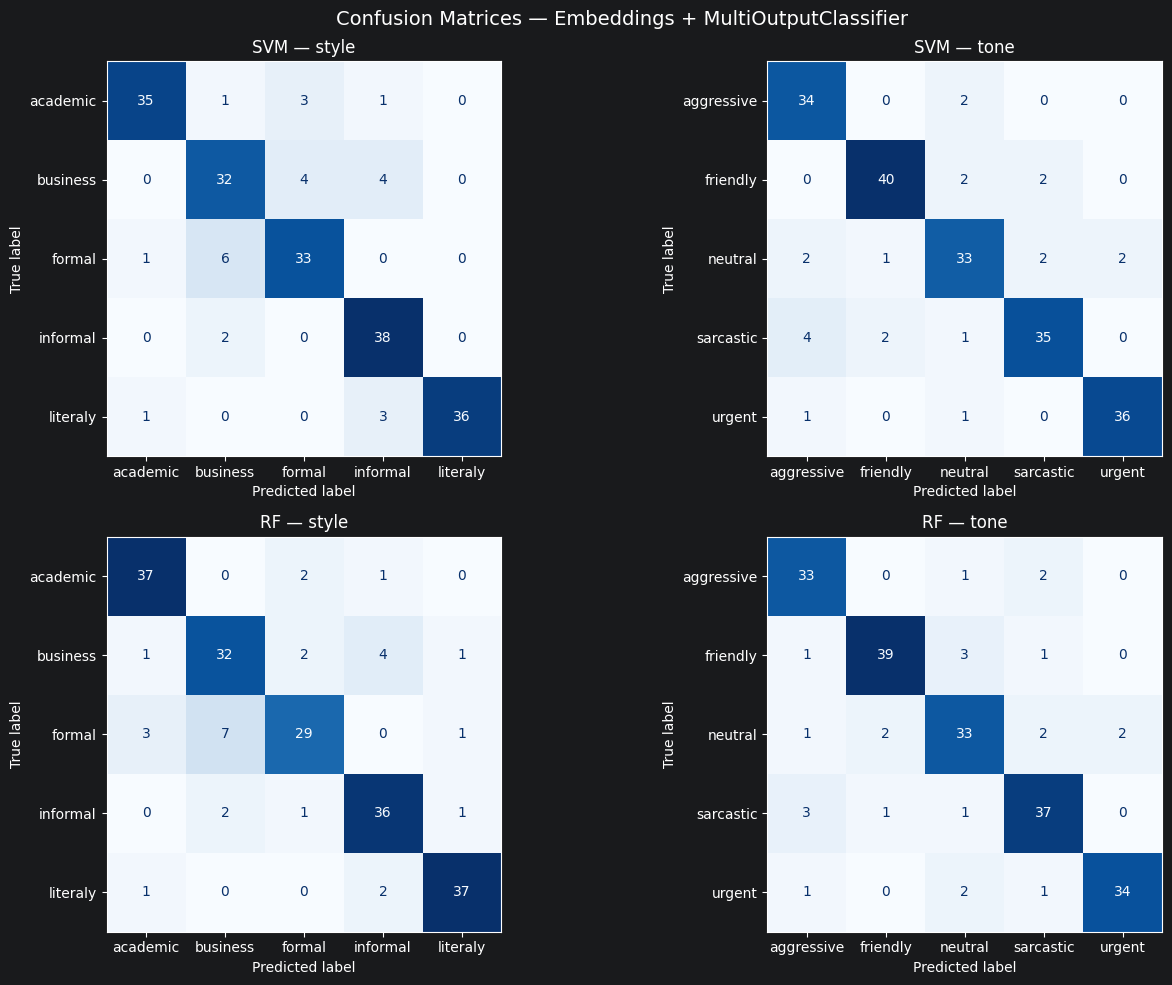

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — Embeddings + MultiOutputClassifier', fontsize=14)

configs = [
    (y_pred_svm[:, 0], y_test[:, 0], le1.classes_, 'SVM', TARGET_1, axes[0, 0]),
    (y_pred_svm[:, 1], y_test[:, 1], le2.classes_, 'SVM', TARGET_2, axes[0, 1]),
    (y_pred_rf[:, 0], y_test[:, 0], le1.classes_, 'RF', TARGET_1, axes[1, 0]),
    (y_pred_rf[:, 1], y_test[:, 1], le2.classes_, 'RF', TARGET_2, axes[1, 1]),
]

for y_pred_col, y_true_col, classes, model_name, target_name, ax in configs:
    cm = confusion_matrix(y_true_col, y_pred_col)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} — {target_name}')

output_dir = Path("saving")
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig('saving/confusion_matrices_03.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. CV Score Comparison Plot

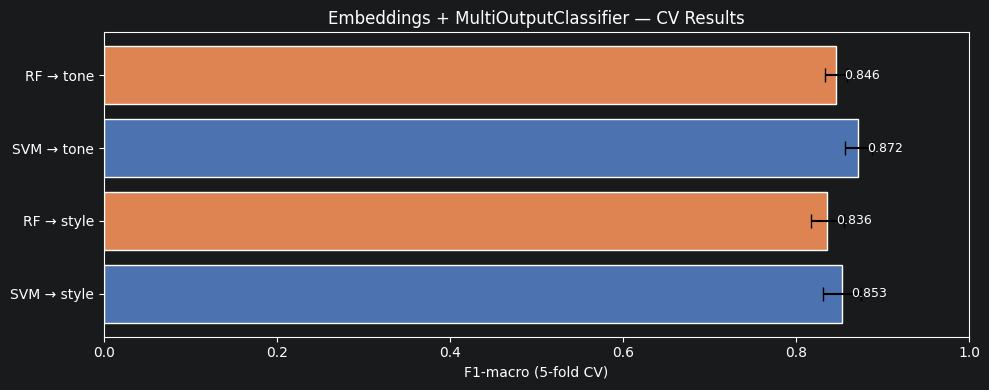

In [64]:
means = {k: v.mean() for k, v in results.items()}
stds = {k: v.std() for k, v in results.items()}

fig, ax = plt.subplots(figsize=(10, 4))
keys = list(means.keys())
vals = [means[k] for k in keys]
errs = [stds[k] for k in keys]
colors = ['#4C72B0', '#DD8452'] * (len(keys) // 2 + 1)

bars = ax.barh(
    keys, vals, xerr=errs, color=colors[:len(keys)],
    capsize=5, edgecolor='white'
)
ax.set_xlabel('F1-macro (5-fold CV)')
ax.set_title('Embeddings + MultiOutputClassifier — CV Results')
ax.set_xlim(0, 1)
for bar, val in zip(bars, vals):
    ax.text(
        val + 0.01, bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center', fontsize=9
    )

plt.tight_layout()
plt.savefig('saving/cv_comparison_03.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary Table

In [65]:
rows = []

for model_name, y_pred in [
    ('SVM', y_pred_svm),
    ('RF', y_pred_rf)
]:
    for col_idx, (tname, le) in enumerate(
        [
            (TARGET_1, le1),
            (TARGET_2, le2)
        ]
    ):
        acc = accuracy_score(
            y_test[:, col_idx],
            y_pred[:, col_idx]
        )

        rows.append(
            {
                'Model': model_name,
                'Target': tname,
                'Accuracy': round(acc, 4),
                'CV F1-macro': round(
                    results[f'{model_name} → {tname}'].mean(),
                    4
                ),
                'CV std': round(
                    results[f'{model_name} → {tname}'].std(),
                    4
                ),
            }
        )

summary_df = pd.DataFrame(rows)

print(summary_df.to_string(index=False))
summary_df

Model Target  Accuracy  CV F1-macro  CV std
  SVM  style     0.870       0.8534  0.0215
  SVM   tone     0.890       0.8721  0.0156
   RF  style     0.855       0.8365  0.0187
   RF   tone     0.880       0.8461  0.0131


,Model,Target,Accuracy,CV F1-macro,CV std
0,SVM,style,0.870,0.8534,0.0215
1,SVM,tone,0.890,0.8721,0.0156
2,RF,style,0.855,0.8365,0.0187
3,RF,tone,0.880,0.8461,0.0131


## 13. End-to-End Pipeline (for inference / deployment)

Once a winning model is chosen, package it as a single sklearn `Pipeline` for clean inference.

In [66]:
best_pipeline = Pipeline(
    [
        ('embed', SpacyEmbeddingVectoriser(nlp=nlp)),
        ('clf', MultiOutputClassifier(
            SVC(
                kernel='rbf', C=10, gamma='scale',
                class_weight='balanced', random_state=42
            ),
            n_jobs=-1
        ))
    ]
)

best_pipeline.fit(X, y)

demo_texts = [
    "Dear Sir or Madam, I am writing to formally request a review of the decision.",
    "omg this is literally the best thing ever lmao",
    "The quarterly results exceeded analyst expectations by a significant margin.",
]

preds = best_pipeline.predict(demo_texts)
for text, pred in zip(demo_texts, preds):
    print(f'\nText: "{text[:80]}"')
    print(f'  → {TARGET_1}: {le1.inverse_transform([pred[0]])[0]}')
    print(f'  → {TARGET_2}: {le2.inverse_transform([pred[1]])[0]}')


Text: "Dear Sir or Madam, I am writing to formally request a review of the decision."
  → style: business
  → tone: sarcastic

Text: "omg this is literally the best thing ever lmao"
  → style: informal
  → tone: sarcastic

Text: "The quarterly results exceeded analyst expectations by a significant margin."
  → style: business
  → tone: neutral


## 14. Save the Pipeline

In [67]:
os.makedirs('data', exist_ok=True)

joblib.dump(best_pipeline, 'data/embedding_multioutput_pipeline.joblib')
joblib.dump({'label_1': le1, 'label_2': le2}, 'data/label_encoders.joblib')

print('Pipeline saved to data/embedding_multioutput_pipeline.joblib')
print('Label encoders saved to data/label_encoders.joblib')

Pipeline saved to data/embedding_multioutput_pipeline.joblib
Label encoders saved to data/label_encoders.joblib
